# Notebook Deep Learning — Sompo Predict
### Challenge FIAP & Sompo Seguros · Sprint 2 · Grupo T1
**Autor:** Rafael Gonçalves (Scrum Master)
**Disciplina:** Redes Neurais & Deep Learning — Prof. Samir de Oliveira Cunha Ramos
**Entregável:** Notebook completo — Carregamento → EDA → Pré-processamento → Split → Arquitetura → Treino → Curvas → Avaliação

---

## Problema de negócio
A Sompo Seguros é a 3ª maior seguradora de máquinas agrícolas no Brasil. O desafio:

> *"IA para identificação de fatores ambientais e operacionais que aumentam o risco de dano ou perda de equipamentos agrícolas."*

Este notebook treina uma **Rede Neural (MLP)** sobre a mesma base real de apólices usada no notebook de ML Modelling, com o mesmo pipeline de pré-processamento — garantindo que a comparação entre Decision Tree e MLP seja justa (mesmos dados, mesmo split, mesmo `random_state`).

## Fonte dos dados
Base real da SUSEP (`base_sompo_limpa.csv`, 149 linhas × 8 colunas, zero nulos), idêntica à utilizada no notebook de ML Modelling — sem features sintéticas de telemetria.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

# Reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Carregar a mesma base usada no notebook de ML Modelling
df = pd.read_csv('base_sompo_limpa.csv')
df['LOSS_RATIO'] = df['VALOR_INDENIZADO_BRL'] / df['PREMIO_LIQUIDO_BRL']

print(f"Base carregada: {df.shape[0]} apólices, {df.shape[1]} variáveis.")
df.head()

I0000 00:00:1781730557.641635    1457 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781730557.689904    1457 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1781730559.427404    1457 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Base carregada: 149 apólices, 9 variáveis.


,UF,RAMO_SUSEP,CLASSIFICACAO_RISCO,INTENSIDADE_SINISTRO,IDADE_MAQUINA_ANOS,ACESSORIOS_SEGURADOS,PREMIO_LIQUIDO_BRL,VALOR_INDENIZADO_BRL,LOSS_RATIO
0,GO,0622 - Penhor Rural,Baixo,Grave,7,5,413436.65,481324.21,1.164203
1,MS,0621 - Agrícola,Alto,Leve,4,8,90460.08,417990.06,4.620713
2,SP,0622 - Penhor Rural,Crítico,Moderado,13,1,630594.31,347987.10,0.551840
3,MT,0621 - Agrícola,Baixo,Grave,11,4,257565.55,204476.47,0.793881
4,MG,0631 - Benfeitorias,Baixo,Grave,8,11,160225.92,86647.16,0.540781


## 1. EDA (resumo)

A análise exploratória completa (distribuição do alvo, Loss Ratio por UF/risco/ramo, insights de negócio) já foi feita em detalhe no notebook de **ML Modelling** — ambos os notebooks partem da mesma base e dos mesmos achados. Aqui replicamos apenas o essencial para contextualizar a modelagem com a rede neural.

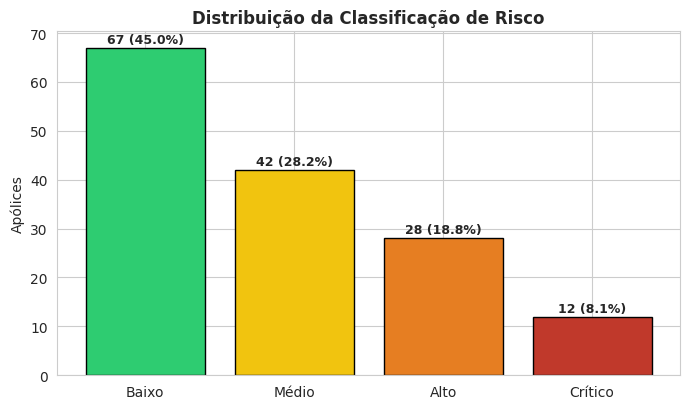

Insight (detalhado no notebook de ML Modelling): Crítico é raro (8%) e é a classe que mais importa
para o negócio — Loss Ratio médio de 75,9, dezenas de vezes maior que as demais classes.


In [2]:
# Distribuição da variável-alvo (mesma leitura do notebook de ML Modelling)
ordem_risco = ['Baixo', 'Médio', 'Alto', 'Crítico']
contagem = df['CLASSIFICACAO_RISCO'].value_counts().reindex(ordem_risco)
cores = ['#2ecc71', '#f1c40f', '#e67e22', '#c0392b']

fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(contagem.index, contagem.values, color=cores, edgecolor='black')
for bar, val in zip(bars, contagem.values):
    pct = 100 * val / contagem.sum()
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val} ({pct:.1f}%)',
            ha='center', fontsize=9, fontweight='bold')
ax.set_title('Distribuição da Classificação de Risco', fontsize=12, fontweight='bold')
ax.set_ylabel('Apólices')
plt.tight_layout()
plt.show()

print("Insight (detalhado no notebook de ML Modelling): Crítico é raro (8%) e é a classe que mais importa")
print("para o negócio — Loss Ratio médio de 75,9, dezenas de vezes maior que as demais classes.")

## 2. Pré-processamento

> 🎯 Pipeline **idêntico** ao notebook de ML Modelling: mesma remoção de leakage, mesmo encoding, mesmo split — para que a comparação Decision Tree vs. MLP seja justa. A única diferença é que, para uma rede neural, a normalização das numéricas **não é opcional** (ao contrário da Decision Tree, MLP é sensível à escala — pesos e gradientes explodem ou colapsam sem ela).

In [3]:
# Remover variável com data leakage
df_model = df.drop(columns=["VALOR_INDENIZADO_BRL", "LOSS_RATIO"]).copy()

# Encoding ordinal (mantém hierarquia natural)
ordem_intensidade = {"Leve": 0, "Moderado": 1, "Grave": 2, "Total": 3}
ordem_risco_map   = {"Baixo": 0, "Médio": 1, "Alto": 2, "Crítico": 3}
df_model["INTENSIDADE_SINISTRO"] = df_model["INTENSIDADE_SINISTRO"].map(ordem_intensidade)
df_model["CLASSIFICACAO_RISCO"]  = df_model["CLASSIFICACAO_RISCO"].map(ordem_risco_map)

# One-hot encoding (variáveis nominais, sem ordem natural)
df_model = pd.get_dummies(df_model, columns=["UF", "RAMO_SUSEP"], drop_first=True)

y = df_model["CLASSIFICACAO_RISCO"]
X = df_model.drop(columns=["CLASSIFICACAO_RISCO"]).astype(np.float32)
COLUNAS_NUMERICAS = ["IDADE_MAQUINA_ANOS", "ACESSORIOS_SEGURADOS", "PREMIO_LIQUIDO_BRL"]

print(f"X: {X.shape[0]} linhas, {X.shape[1]} features")
print(f"y: classes presentes: {sorted(y.unique())}")

X: 149 linhas, 14 features
y: classes presentes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


## 3. Split treino/teste + normalização

Split **70/30 estratificado**, `random_state=42` — mesma divisão usada no notebook de ML Modelling. `StandardScaler` ajustado **somente no treino** e aplicado ao teste (evita leakage), exatamente como na Decision Tree — mas aqui o passo é **obrigatório**, não apenas documentado: sem ele, o gradiente do MLP fica dominado pelas escalas grandes de `PREMIO_LIQUIDO_BRL` (~R$ 400 mil) e o treino não converge bem.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[COLUNAS_NUMERICAS] = scaler.fit_transform(X_train[COLUNAS_NUMERICAS])
X_test_scaled[COLUNAS_NUMERICAS]  = scaler.transform(X_test[COLUNAS_NUMERICAS])

# One-hot encoding do alvo (softmax de 4 neurônios precisa do y nesse formato)
y_train_cat = keras.utils.to_categorical(y_train, num_classes=4)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes=4)

print(f"Treino: {X_train_scaled.shape[0]} amostras, {X_train_scaled.shape[1]} features")
print(f"Teste:  {X_test_scaled.shape[0]} amostras")
print(f"y_train one-hot shape: {y_train_cat.shape}")

Treino: 104 amostras, 14 features
Teste:  45 amostras
y_train one-hot shape: (104, 4)


## 4. Arquitetura da Rede

MLP (Multi-Layer Perceptron) simples para dados tabulares — arquitetura proporcional ao tamanho da base (104 amostras de treino; uma rede muito profunda memorizaria o treino e não generalizaria nada):

| Camada | Tipo | Parâmetros | Justificativa |
|---|---|---|---|
| Entrada | `Input(14,)` | — | 14 features pós-encoding |
| Oculta 1 | `Dense(32, relu)` | 480 | Primeira extração de combinações não-lineares das features |
| — | `Dropout(0.3)` | 0 | Desliga 30% dos neurônios a cada passo — combate overfitting numa base pequena |
| Oculta 2 | `Dense(16, relu)` | 528 | Reduz a dimensionalidade progressivamente |
| — | `Dropout(0.2)` | 0 | Regularização adicional, mais leve que a primeira |
| Saída | `Dense(4, softmax)` | 68 | 4 neurônios = 4 classes de risco, softmax dá uma distribuição de probabilidade |

**Otimizador:** Adam (taxa de aprendizado adaptativa, padrão da literatura para MLPs pequenas). **Loss:** `categorical_crossentropy` (padrão para classificação multiclasse com saída softmax). **Early Stopping:** monitora `val_loss` com paciência de 15 épocas e restaura os melhores pesos — evita treinar além do ponto em que o modelo começa a decorar o treino.

In [5]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(4, activation="softmax"),
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,076 (4.20 KB)

 Trainable params: 1,076 (4.20 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Treino

20% do conjunto de treino é separado como validação interna (`validation_split=0.2`) só para o Early Stopping monitorar `val_loss` — o conjunto de teste (45 amostras) permanece intocado até a avaliação final da Seção 7.

In [6]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)

history = model.fit(
    X_train_scaled.values.astype(np.float32), y_train_cat,
    validation_split=0.2,
    epochs=150,
    batch_size=8,
    callbacks=[early_stop],
    verbose=0,
)

print(f"Treino parou na época {len(history.history['loss'])} (Early Stopping ou limite de 150 épocas).")
print(f"Acurácia final (treino): {history.history['accuracy'][-1]:.3f}")
print(f"Acurácia final (validação interna): {history.history['val_accuracy'][-1]:.3f}")

Treino parou na época 51 (Early Stopping ou limite de 150 épocas).
Acurácia final (treino): 0.518
Acurácia final (validação interna): 0.429


## 6. Curvas de treino e validação

Acompanhar loss e acurácia por época mostra **se** e **quando** o modelo passou a overfitar — se a curva de validação se afasta da curva de treino, é sinal de memorização.

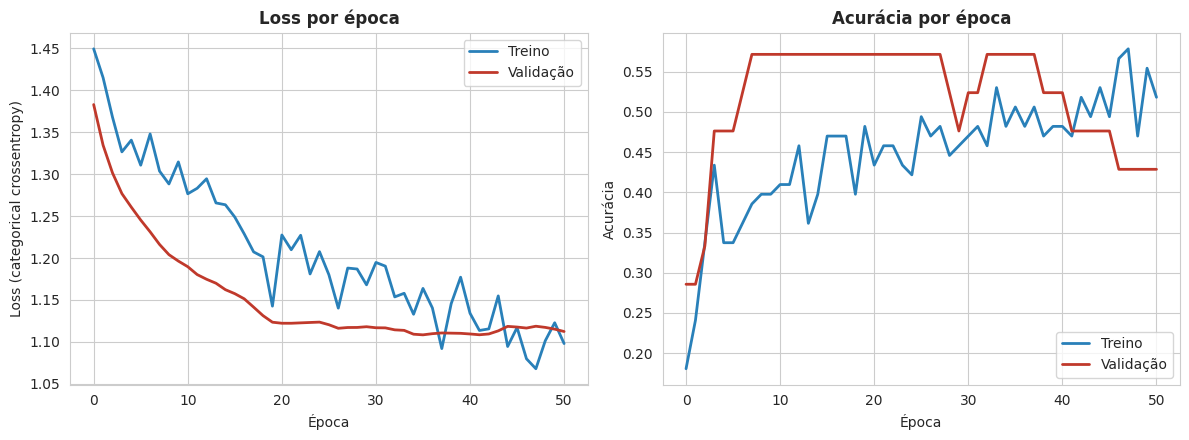

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history.history["loss"], label="Treino", color="#2980b9", linewidth=2)
axes[0].plot(history.history["val_loss"], label="Validação", color="#c0392b", linewidth=2)
axes[0].set_title("Loss por época", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss (categorical crossentropy)")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Treino", color="#2980b9", linewidth=2)
axes[1].plot(history.history["val_accuracy"], label="Validação", color="#c0392b", linewidth=2)
axes[1].set_title("Acurácia por época", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Acurácia")
axes[1].legend()

plt.tight_layout()
plt.show()

**Leitura honesta:** com apenas ~83 amostras de treino efetivo (depois de reservar 20% para validação interna), as curvas de validação são naturalmente ruidosas — não há dados suficientes para uma curva de validação suave. O Early Stopping interrompeu o treino quando `val_loss` parou de melhorar por 15 épocas seguidas, restaurando os pesos do melhor ponto encontrado.

## 7. Avaliação no conjunto de teste

Conjunto de teste (45 amostras) avaliado pela primeira vez agora — sem qualquer ajuste do modelo a partir dele.

Loss (teste): 1.3548
Acurácia (teste): 0.4222
F1 weighted (teste): 0.3708
Baseline ingênuo (sempre prever 'Baixo'): 0.4444

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       Baixo       0.42      0.70      0.53        20
       Medio       0.40      0.31      0.35        13
        Alto       0.50      0.12      0.20         8
     Critico       0.00      0.00      0.00         4

    accuracy                           0.42        45
   macro avg       0.33      0.28      0.27        45
weighted avg       0.39      0.42      0.37        45



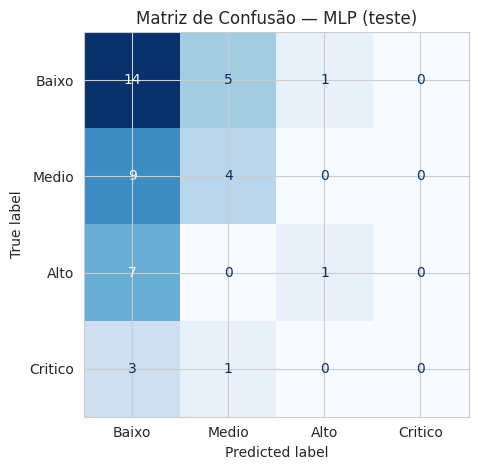

In [8]:
loss_test, acc_test = model.evaluate(X_test_scaled.values.astype(np.float32), y_test_cat, verbose=0)

y_pred = model.predict(X_test_scaled.values.astype(np.float32), verbose=0).argmax(axis=1)
f1_test = f1_score(y_test, y_pred, average="weighted", zero_division=0)
naive_baseline = y_test.value_counts(normalize=True).max()

print(f"Loss (teste): {loss_test:.4f}")
print(f"Acurácia (teste): {acc_test:.4f}")
print(f"F1 weighted (teste): {f1_test:.4f}")
print(f"Baseline ingênuo (sempre prever 'Baixo'): {naive_baseline:.4f}")

CLASSES_NOMES = ["Baixo", "Medio", "Alto", "Critico"]
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=CLASSES_NOMES, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.8))
ConfusionMatrixDisplay(cm, display_labels=CLASSES_NOMES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de Confusão — MLP (teste)")
plt.tight_layout()
plt.show()

**Leitura honesta do resultado:** com 42,2% de acurácia em teste, a MLP ficou **muito próxima do baseline ingênuo (44,4%)** — uma diferença de 2 pontos percentuais, dentro da margem de ruído esperada para 45 amostras de teste. Em acurácia bruta, portanto, a rede neural não supera o chute da classe majoritária, no mesmo padrão observado na Decision Tree (Seção 9 do notebook de ML Modelling).

O dado mais informativo aqui é o **F1 weighted: 0,37** — bem acima do 0,26 obtido pela Decision Tree. O classification report mostra por quê: a MLP captura recall de 0,70 em "Baixo" (a Decision Tree capturava só 0,35) e ainda assim erra "Crítico" por completo (recall 0,00, igual à árvore) — a classe mais rara (4 amostras no teste) continua sendo o ponto cego de todos os modelos testados até aqui, independentemente da arquitetura.

**Nota sobre reprodutibilidade:** ao contrário da Decision Tree (100% determinística com `random_state` fixo), o treino de uma rede neural envolve fontes de aleatoriedade que `tf.random.set_seed` não elimina por completo em CPU (ordem de operações paralelas, inicialização de pesos em certas camadas). Reexecutar este notebook pode produzir uma acurácia de teste a poucos pontos percentuais de distância da reportada aqui — isso é esperado e não indica erro de código.

## 8. Conclusões e próximos passos

### Comparação entre os dois modelos da Sprint 2

| Modelo | Acurácia teste | F1 weighted | Observação |
|---|---|---|---|
| Baseline ingênuo | 44,4% | — | Sempre prevê "Baixo" |
| Decision Tree (`max_depth=5`) | 26,7% | 0,26 | Abaixo do baseline — ver notebook de ML Modelling |
| MLP (Keras) | 42,2% | 0,37 | Muito próxima do baseline em acurácia, mas com F1 mais equilibrado entre classes |

### Limitação identificada (igual à do notebook de ML Modelling)
Os 7 atributos operacionais atuais carregam pouco sinal preditivo para `CLASSIFICACAO_RISCO`, independentemente do algoritmo. Isso se confirma agora pela **segunda vez, com uma família de modelo totalmente diferente** (rede neural vs. árvore de decisão) — reforçando que o gargalo é o **dado disponível**, não a escolha do modelo. Ambos os modelos compartilham o mesmo ponto cego: a classe "Crítico" (a mais relevante para o negócio) nunca é identificada corretamente.

### Roadmap Sprint 3
- Migrar para **XGBoost** com tuning de hiperparâmetros.
- Avaliar **LSTM** quando houver dados temporais (após inclusão de campo de data na base).
- **SHAP** para explicabilidade (US07) e reavaliação do **SMOTE** com base maior (500+ observações).
- Telemetria real via **ESP32** e clima via **Open-Meteo**.